In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,classification_report,accuracy_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier

In [2]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


0.7662337662337663
              precision    recall  f1-score   support

           0       0.82      0.81      0.82        99
           1       0.67      0.69      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154

0.7597402597402597
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

0.7662337662337663
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg     

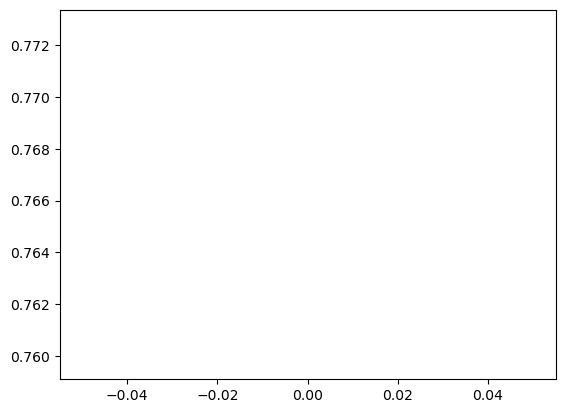

In [3]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
acc_score=[]
for i in range(31,51):
    rf=RandomForestClassifier(n_estimators=i,criterion='entropy',random_state=42)
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    print(accuracy_score(y_test,y_pred))
    acc_score.append(accuracy_score(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    plt.plot(accuracy_score(y_test,y_pred))
print(max(acc_score))

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,classification_report,accuracy_score
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
x=data.data
y=data.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
rf=RandomForestClassifier(random_state=42)
param_grid={
    'n_estimators':[100,200,300],
    'max_depth':[None,5,10,20],
    'max_features':['sqrt','log2',None],
    'max_samples':[None,0.6,0.8]
}
grid=GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)
grid.fit(x_train,y_train)
print('best paRAMETERS',grid.best_params_)
y_pred=grid.best_estimator_.predict(x_test)
print(classification_report(y_test,y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
best paRAMETERS {'max_depth': None, 'max_features': 'sqrt', 'max_samples': None, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

